<a href="https://colab.research.google.com/github/alexandrov-data/1_-LTV-CAC-ROI...-/blob/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B1%D0%B8%D0%B7%D0%BD%D0%B5%D1%81_%D0%BF%D0%BE%D0%BA%D0%B0%D0%B7%D0%B0%D1%82%D0%B5%D0%BB%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Подключим библиотеки, которые понадобятся нам для работы.

In [ ]:
import pandas as pd  # Работа с табличными данными, DataFrame, чтение/запись файлов, группировки
from datetime import datetime, timedelta  # Работа с датами и временем, разница между датами
from matplotlib import pyplot as plt  # Построение графиков, диаграмм, визуализация данных
import numpy as np  # Математические операции, массивы, линейная алгебра, случайные числа

### Загрузим данные и подготовим их к анализу.

Загрузим данные о визитах, заказах и рекламных расходах из CSV-файлов в память.

Проанализируем данные и проведем их предобработку. Проверим наличие пропусков и дубликатов. Убедимся, что типы данных в каждом столбце соответствуют их содержимому. Обратим особое внимание на столбцы с датами и временем.

#### Загрузим данные из файлов.

In [ ]:
# Использую try/except, чтобы при отсутствии файла программа не упала, а сообщила об ошибке
try:
    visits = pd.read_csv("/datasets/visits_info_short.csv")
    print("Файл 'visits_info_short.csv'успешно загружен!")
except FileNotFoundError:
    print("Ошибка: Файл не найден!")

Файл 'visits_info_short.csv'успешно загружен!


In [ ]:
try:
    orders = pd.read_csv("/datasets/orders_info_short.csv")
    print("Файл 'datasets/orders_info_short.csv' успешно загружен!")
except FileNotFoundError:
    print("Ошибка: Файл не найден!")

Файл 'datasets/orders_info_short.csv' успешно загружен!


In [ ]:
try:
    costs = pd.read_csv("/datasets/costs_info_short.csv")
    print("Файл 'datasets/costs_info_short.csv' успешно загружен!")
except FileNotFoundError:
    print("Ошибка: Файл не найден!")

Файл 'datasets/costs_info_short.csv' успешно загружен!


#### Посмотрим на данные и типы данных.

In [ ]:
visits.sample(10)

,User Id,Region,Device,Channel,Session Start,Session End
280229,689373801813,Germany,iPhone,organic,2019-09-16 16:20:02,2019-09-16 17:34:58
215548,34457374058,UK,iPhone,LeapBob,2019-05-18 23:41:29,2019-05-19 00:06:16
235252,588668036507,UK,Android,organic,2019-06-27 03:37:45,2019-06-27 03:59:53
101979,568511887977,United States,PC,TipTop,2019-08-09 19:01:03,2019-08-09 19:38:21
118078,37203752631,United States,iPhone,FaceBoom,2019-08-22 20:10:07,2019-08-22 20:10:55
27235,331729402570,United States,Mac,YRabbit,2019-05-28 00:06:52,2019-05-28 00:22:45
187687,638317114157,United States,Android,MediaTornado,2019-10-15 06:31:17,2019-10-15 06:35:15
247214,601628572614,Germany,iPhone,OppleCreativeMedia,2019-07-19 07:01:39,2019-07-19 07:29:27
29414,58889468773,United States,iPhone,FaceBoom,2019-05-31 21:18:19,2019-05-31 22:03:33
256429,497486359227,France,Android,WahooNetBanner,2019-08-06 14:09:13,2019-08-06 14:38:37


In [ ]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   User Id        309901 non-null  int64 
 1   Region         309901 non-null  object
 2   Device         309901 non-null  object
 3   Channel        309901 non-null  object
 4   Session Start  309901 non-null  object
 5   Session End    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB


In [ ]:
orders.sample(10)

,User Id,Event Dt,Revenue
26781,273473165622,2019-10-26 07:07:39,4.99
8497,128193558792,2019-07-19 17:52:30,4.99
29474,496467788437,2019-06-15 08:37:23,4.99
32146,75120659023,2019-08-01 07:28:20,4.99
21649,270988486464,2019-10-02 16:40:50,4.99
16375,245901266573,2019-09-05 18:28:27,4.99
33827,474325795906,2019-08-23 12:17:59,4.99
15980,35972474283,2019-09-03 00:23:14,4.99
25284,271825045458,2019-10-19 09:04:47,4.99
4653,759965900663,2019-06-24 02:26:09,4.99


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  object 
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB


In [ ]:
costs.sample(10)

,dt,Channel,costs
1158,2019-07-18,LeapBob,7.56
349,2019-10-17,MediaTornado,3.36
951,2019-06-21,AdNonSense,19.95
1033,2019-09-11,AdNonSense,9.45
866,2019-09-24,YRabbit,7.92
1477,2019-06-07,WahooNetBanner,26.40
1317,2019-06-27,OppleCreativeMedia,10.25
740,2019-05-21,YRabbit,12.30
837,2019-08-26,YRabbit,3.78
172,2019-10-20,FaceBoom,225.50


In [ ]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   Channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


#### Приводим строковые значения в датафреймах к нижнему регистру.

In [ ]:
dfs = {"visits": visits,
       "orders": orders,
       "costs": costs}

for name, df in dfs.items():
    dfs[name] = df.applymap(lambda x: x.lower() if isinstance(x, str) else x)


/tmp/ipykernel_6603/1819045391.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dfs[name] = df.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [ ]:
# Посмотрим на получившиеся изменения.
for name, df in dfs.items():
    print(f"DataFrame '{name}':\n", df.head(), "\n")

DataFrame 'visits':
         User Id         Region   Device  Channel        Session Start  \
0  981449118918  united states   iphone  organic  2019-05-01 02:36:01   
1  278965908054  united states   iphone  organic  2019-05-01 04:46:31   
2  590706206550  united states      mac  organic  2019-05-01 14:09:25   
3  326433527971  united states  android   tiptop  2019-05-01 00:29:59   
4  349773784594  united states      mac  organic  2019-05-01 03:33:35   

           Session End  
0  2019-05-01 02:45:01  
1  2019-05-01 04:47:35  
2  2019-05-01 15:32:08  
3  2019-05-01 00:54:25  
4  2019-05-01 03:57:40   

DataFrame 'orders':
         User Id             Event Dt  Revenue
0  188246423999  2019-05-01 23:09:52     4.99
1  174361394180  2019-05-01 12:24:04     4.99
2  529610067795  2019-05-01 11:34:04     4.99
3  319939546352  2019-05-01 15:34:40     4.99
4  366000285810  2019-05-01 13:59:51     4.99 

DataFrame 'costs':
            dt   Channel  costs
0  2019-05-01  faceboom  113.3
1  2019

#### Посчитаем явные дубликаты по датафреймам.

In [ ]:
for name, df in dfs.items():
    print(f"Сумма явных дубликатов датафрейма'{name}'",df.duplicated().sum())

Сумма явных дубликатов датафрейма'visits' 0
Сумма явных дубликатов датафрейма'orders' 0
Сумма явных дубликатов датафрейма'costs' 0


#### Проверим наличие пропусков в датафреймах.

In [ ]:
for name, df in dfs.items():
    print(f"Прокуски в датафрейма'{name}'= ",df.isnull().values.any())

Прокуски в датафрейма'visits'=  False
Прокуски в датафрейма'orders'=  False
Прокуски в датафрейма'costs'=  False


#### Приведем столбцы с датой к соответствующему типу.

In [ ]:
#Для начала приведем к нижнему регистру имена столбцов и переименуем их.

visits.rename(columns=lambda x: x.lower().replace('session start', 'session_start')
                                         .replace('session end', 'session_end')
                                         .replace('user id', 'user_id'),  inplace=True)

orders.rename(columns=lambda x: x.lower().replace('event dt', 'event_dt')
                                         .replace('user id', 'user_id'),inplace=True)

costs.rename(columns=lambda x: x.lower(),inplace=True)

#Исправим типы столбцов там, где это нужно.
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_end'])

orders['event_dt'] = pd.to_datetime(orders['event_dt'])

#costs['dt'] = pd.to_datetime(costs['dt']) # Вариант datetime64[ns]


costs['dt'] = pd.to_datetime(costs['dt']).dt.date #  Вариант тип данных object

Результат предобработки данных.

In [ ]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        309901 non-null  int64         
 1   region         309901 non-null  object        
 2   device         309901 non-null  object        
 3   channel        309901 non-null  object        
 4   session_start  309901 non-null  datetime64[ns]
 5   session_end    309901 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 14.2+ MB


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   40212 non-null  int64         
 1   event_dt  40212 non-null  datetime64[ns]
 2   revenue   40212 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 942.6 KB


In [ ]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


Промежуточные выводы: после проведенной предобработки данных можно с уверенностью сказать, что во всех трех таблицах отсутствуют пропуски, дубликаты. Типы столбцов, хранящие дату и время, приведены в соответствие.

### Зададим функции для расчёта и анализа LTV, ROI, удержания и конверсии.
Это функции для вычисления значений метрик:

- `get_profiles()` — для создания профилей пользователей,

- `get_retention()` — для подсчёта Retention Rate,

- `get_conversion()` — для подсчёта конверсии,

- `get_ltv()` — для подсчёта LTV.

А также функции для построения графиков:

- `filter_data()` — для сглаживания данных,

- `plot_retention()` — для построения графика Retention Rate,

- `plot_conversion()` — для построения графика конверсии,

- `plot_ltv_roi` — для визуализации LTV и ROI.

#### Функции для вычисления значений метри :

#### Функция для создания пользовательских профилей .

In [ ]:
 def get_profiles(sessions, orders, costs):

   # находим параметры первых посещений
    profiles = (
        sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло

    #Вариант тип данных object  datetime64[ns]
    profiles['dt'] = profiles['first_ts'].dt.date


    #Вариант тип данных datetime64[ns]
    #profiles['dt'] = profiles['first_ts'].dt.to_period('M').dt.to_timestamp()


    profiles['month'] = profiles['first_ts'].dt.to_period('M').dt.to_timestamp()

    #profiles['month'] = profiles['first_ts'].astype('datetime64[M]')

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    # объединяем траты на рекламу и число привлечённых пользователей
    costs = costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    costs['acquisition_cost'] = costs['costs'] / costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

#### Функция для расчета удержания.

In [ ]:
def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(days=horizon_days - 1)
    result_raw  = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

#### Функция для расчета конверсии.

In [ ]:
# функция для расчёта конверсии

def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

####  Функция для расчета LTV и ROI.

In [ ]:
# функция для расчёта LTV и ROI

def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC,
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    )

 #### Функции для построения графиков:

#### Функция для сглаживания фрейма.

In [ ]:
def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean()
    return df

#### Функция для визуализации удержания.

In [ ]:
def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )

    plt.tight_layout()
    plt.show()

#### Функция для визуализации конверсии.

In [ ]:
def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

#### Функция для визуализации LTV и ROI.

In [ ]:
def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]

    #print(columns)
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    #print(filtered_data)
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей CAC ')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

#### Функция для исследовательского анализа.

In [ ]:
 def summary_tables(data,parameters):

        total_users =( data.groupby(parameters)
              .agg({'user_id': 'nunique'})
              .rename(columns={'user_id': 'total_users'})
              .reset_index()
             )
        paying_users = (data.query('payer == True ')
                .groupby(parameters)['user_id']
                .nunique()
                .to_frame()
                .rename(columns={'user_id':'paying_users'})
                .reset_index()
               )
        parameters_users = total_users.merge(paying_users, on= parameters, how='left').fillna(0)
        parameters_users['paying_share_%'] = (parameters_users['paying_users'] / parameters_users['total_users']
                                           )*100


        return parameters_users

### Исследовательский анализ данных

* Составим профили пользователей. Определим минимальную и максимальную даты привлечения пользователей.
* Выясним, из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей. Построим таблицу, отражающую количество пользователей и долю платящих из каждой страны.
* Узнаем, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. Построим таблицу, отражающую количество пользователей и долю платящих для каждого устройства.
* Изучим рекламные источники привлечения и определим каналы, из которых пришло больше всего платящих пользователей. Построим таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения.

После каждого пункта сформулируем выводы.

#### Составим профили пользователей и определим min, max дату привлечения пользователей.

In [ ]:
#Составим профили пользователей.
profiles = get_profiles(visits,orders,costs)
profiles.sample(10)

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
57092,379103345218,2019-10-01 03:14:38,TipTop,iPhone,United States,2019-10-01,2019-10-01,False,3.570946
20776,138107245823,2019-06-05 23:05:34,organic,PC,United States,2019-06-05,2019-06-01,False,0.000000
34287,227405361733,2019-10-19 06:43:07,organic,Mac,United States,2019-10-19,2019-10-01,False,0.000000
69067,458335922457,2019-08-14 07:30:04,lambdaMediaAds,Mac,France,2019-08-14,2019-08-01,False,0.320000
7947,53066829352,2019-05-13 17:28:33,RocketSuperAds,iPhone,United States,2019-05-13,2019-05-01,False,0.516176
35398,235151541819,2019-08-28 23:09:46,organic,iPhone,United States,2019-08-28,2019-08-01,False,0.000000
11955,79488157364,2019-06-15 10:28:47,organic,PC,United States,2019-06-15,2019-06-01,False,0.000000
90536,602336238684,2019-05-31 07:27:20,organic,Android,Germany,2019-05-31,2019-05-01,False,0.000000
23023,153569759094,2019-06-02 10:00:10,YRabbit,iPhone,United States,2019-06-02,2019-06-01,False,0.267857
79488,528115058817,2019-06-25 07:09:45,TipTop,Mac,United States,2019-06-25,2019-06-01,True,2.659091


In [ ]:
#Определим min, max даты привлечения пользователей.

print('Минимальная дата привлечения пользователя:',profiles['first_ts'].min())
print('Максимальная дата привлечения пользователя:',profiles['first_ts'].max())


Минимальная дата привлечения пользователя: 2019-05-01 00:00:41
Максимальная дата привлечения пользователя: 2019-10-27 23:59:04


In [ ]:
observation_date = datetime(2019, 11, 1).date()  # момент анализа
horizon_days = 14 # горизонт анализа

Вывод: В этой части работы были созданы профили пользователей, а также установлены крайние даты.

#### Выясним, из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей.

In [ ]:
# Определим уникальные строки из колонки «Регион», тем самым найдем страны,
# из которых приходят пользователи в приложение.

print(profiles['region'].unique())


['United States' 'France' 'Germany' 'UK']


In [ ]:
# Применим функцию.

region_users = summary_tables(profiles,"region")
print('Таблица, отражающая количество пользователей и доли платящих пользователей по регионам: \n')
print(region_users.sort_values(by ='paying_share_%', ascending=False))


Таблица, отражающая количество пользователей и доли платящих пользователей по регионам: 

          region  total_users  paying_users  paying_share_%
3  United States       100002          6902        6.901862
1        Germany        14981           616        4.111875
2             UK        17575           700        3.982930
0         France        17450           663        3.799427


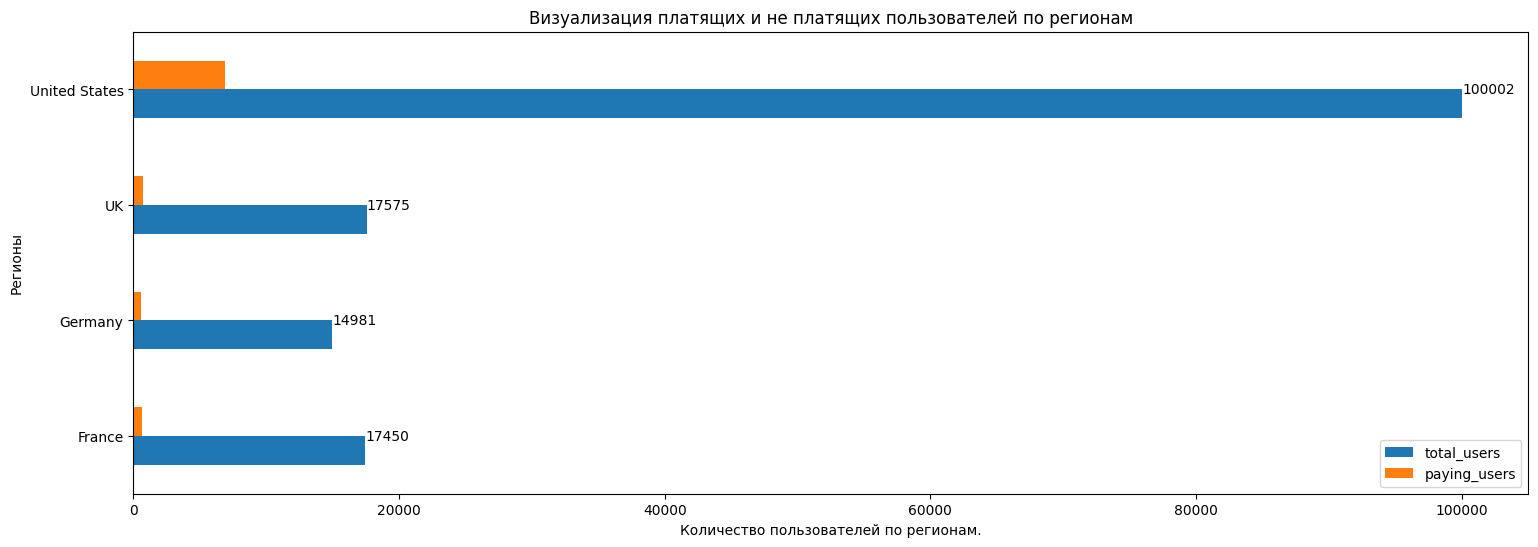

In [ ]:
#Визуализация количества пользователей, приходящих в приложение, по регионам.
region_users = region_users.drop(columns=['paying_share_%'])
ax = region_users.set_index('region').plot.barh(figsize=(18, 6),
                                                title="Визуализация платящих и не платящих пользователей по регионам")
for index, row in region_users.iterrows():
    plt.text(row['total_users'] + 10, index, f"{row['total_users']:.0f}", va='center')

plt.xlabel("Количество пользователей по регионам.")
plt.ylabel("Регионы")
# Показываем график
plt.show()

Вывод:
 - Приложение доступно в следующих странах: США, Франция, Германия и Великобритания. Наибольшее количество пользователей зарегистрировано в США — 100 002. Наименьшее количество пользователей — во Франции, всего 17 450. При этом максимальное соотношение платящих пользователей к не платящим не превышает 6,9% — это в США, самое большое значение.

#### Узнаем, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. Построим таблицу, отражающую количество пользователей и долю платящих для каждого устройства.

In [ ]:
# Определим типы устройств.
print(profiles['device'].unique())

['Mac' 'iPhone' 'PC' 'Android']


In [ ]:
# Удостоверимся, с каждого устройства совершали покупки.
print(profiles.query('payer == True ')['device'].unique())

['Mac' 'Android' 'iPhone' 'PC']


In [ ]:
device_users = summary_tables(profiles,"device")

print('Таблица, отражающая количество пользователей и доли платящих пользователей относительно устройства: \n')
print(device_users.sort_values(by ='paying_share_%', ascending=False))


Таблица, отражающая количество пользователей и доли платящих пользователей относительно устройства: 

    device  total_users  paying_users  paying_share_%
1      Mac        30042          1912        6.364423
3   iPhone        54479          3382        6.207897
0  Android        35032          2050        5.851793
2       PC        30455          1537        5.046790


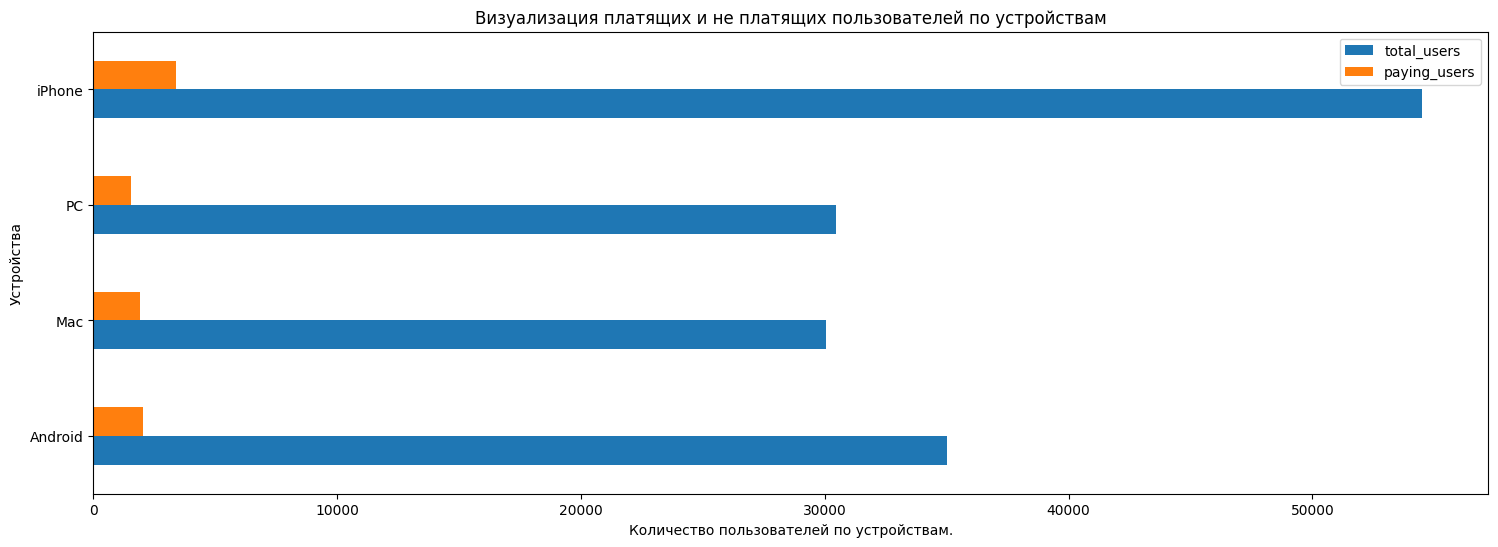

In [ ]:
#Визуализация количества пользователей, приходящих в приложение, по устройствам.

device_users = device_users.drop(columns=['paying_share_%'])
device_users.set_index('device').plot.barh(  figsize=(18, 6), title="Визуализация платящих и не платящих пользователей по устройствам")
plt.xlabel("Количество пользователей по устройствам.")
plt.ylabel("Устройства")
plt.show()


Вывод :
- Исследование демонстрирует что пользователи используют устройства «Mac», «Android», «iPhone» и «PC».
- Среди них 54 479 человек используют iPhone, из которых только 6,2% совершают покупки.
- Наиболее активными в плане платежей оказались владельцы устройств «Mac».

#### Изучим рекламные источники привлечения и определим каналы, из которых придет больше всего платящих пользователей. Построим таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения.

In [ ]:
print('Рекламные каналы : \n',profiles['channel'].unique())

Рекламные каналы : 
 ['FaceBoom' 'organic' 'AdNonSense' 'YRabbit' 'MediaTornado'
 'RocketSuperAds' 'LeapBob' 'TipTop' 'WahooNetBanner' 'OppleCreativeMedia'
 'lambdaMediaAds']


In [ ]:
channel_users = summary_tables(profiles,"channel")

print("""Таблица, отражающая количество пользователей и доли платящих пользователей
относительно канала привлечения. \n""")
print(channel_users.sort_values(by = 'paying_users' ,ascending=False))



Таблица, отражающая количество пользователей и доли платящих пользователей
относительно канала привлечения. 

               channel  total_users  paying_users  paying_share_%
1             FaceBoom        29144          3557       12.204914
6               TipTop        19561          1878        9.600736
10             organic        56439          1160        2.055316
7       WahooNetBanner         8553           453        5.296387
0           AdNonSense         3880           440       11.340206
5       RocketSuperAds         4448           352        7.913669
2              LeapBob         8553           262        3.063253
4   OppleCreativeMedia         8605           233        2.707728
9       lambdaMediaAds         2149           225       10.469986
8              YRabbit         4312           165        3.826531
3         MediaTornado         4364           156        3.574702


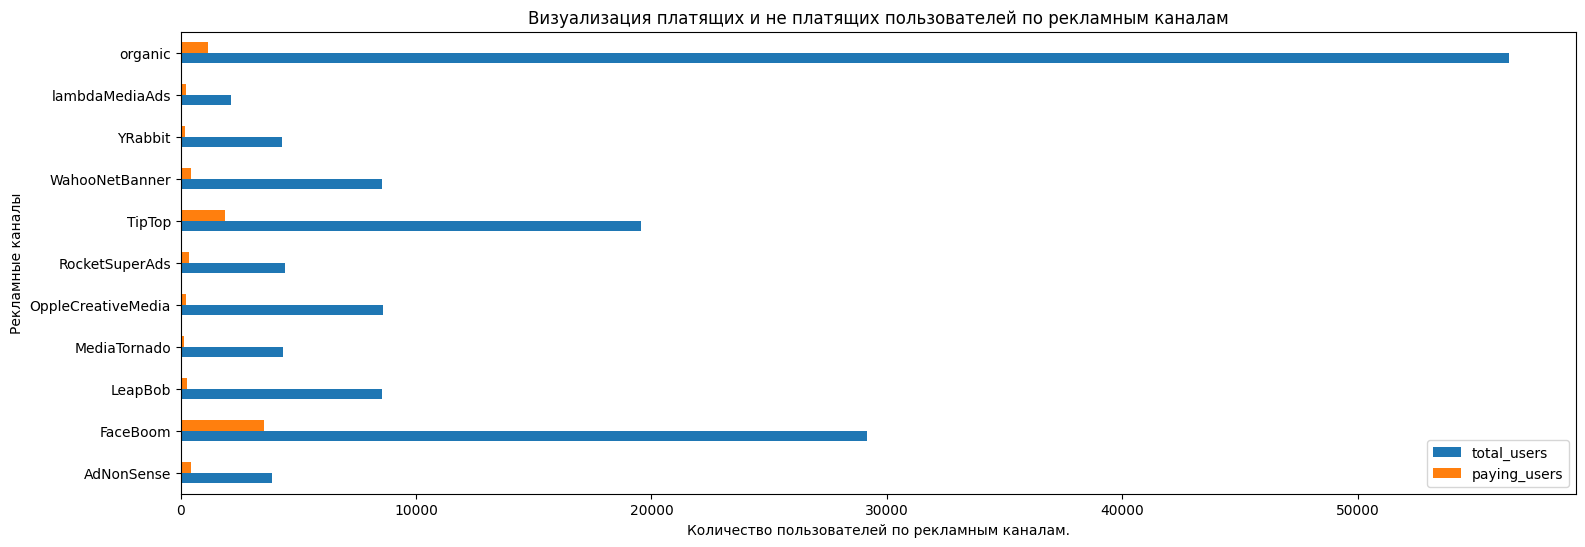

In [ ]:
#Визуализация количества пользователей, приходящих в приложение, по рекламным каналам.

channel_users = channel_users.drop(columns=['paying_share_%'])
channel_users.set_index('channel').plot.barh(  figsize=(18, 6), title="Визуализация платящих и не платящих пользователей по рекламным каналам")

plt.xlabel("Количество пользователей по рекламным каналам.")
plt.ylabel("Рекламные каналы")
plt.show()


Вывод:
Представлены следующие рекламные каналы: 'FaceBoom', 'organic', 'AdSense', 'Yabbit', 'MediaTornado', 'RocketSuperAds', 'LeapBob', 'TipTop', 'WahooNetBanner', 'OppleCreativeMedia', 'LambdaMediaAds'.
Из них три наиболее популярных среди пользователей: «organic», «FaceBoom» и «TipTop». При этом у этих рекламных каналов разная эффективность в привлечении покупателей. Лидером по этому показателю является «FaceBoom» с 12,2%.

### Маркетинг

- Посчитаем общую сумму расходов на маркетинг.
- Выясним, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник.
- Построим график с визуализацией динамики изменения расходов во времени по неделям по каждому источнику. Затем на другом графике визуализируем динамику изменения расходов во времени по месяцам по каждому источнику.
- Узнаем, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника. Используем профили пользователей.

Напишем промежуточные выводы.

#### Посчитаем общую сумму расходов на маркетинг.

In [ ]:
print('Общая сумма, потраченная на маркетинг.',costs['costs'].sum())


Общая сумма, потраченная на маркетинг. 105497.30000000002


#### Выясним, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник.

In [ ]:
chenel_costs = costs.groupby('channel')['costs'].sum().sort_values(ascending=False).reset_index()
print("Суммартые траты по карждому из рекламных источников: \n \n",chenel_costs)

Суммартые траты по карждому из рекламных источников: 
 
               channel     costs
0              TipTop  54751.30
1            FaceBoom  32445.60
2      WahooNetBanner   5151.00
3          AdNonSense   3911.25
4  OppleCreativeMedia   2151.25
5      RocketSuperAds   1833.00
6             LeapBob   1797.60
7      lambdaMediaAds   1557.60
8        MediaTornado    954.48
9             YRabbit    944.22


#### Построим график с визуализацией динамики изменения расходов во времени по неделям по каждому источнику.

In [ ]:
# Этот код можно было написать короче, но из-за проблем с типами данных он стал длиннее в два раза)

# Подготовим столбцы со значением недели и месяца.
costs['week'] = pd.to_datetime(costs['dt'])
costs['week'] = costs['week'].dt.isocalendar().week

costs['month'] = pd.to_datetime(costs['dt'])
costs['month'] = costs['month'].dt.month

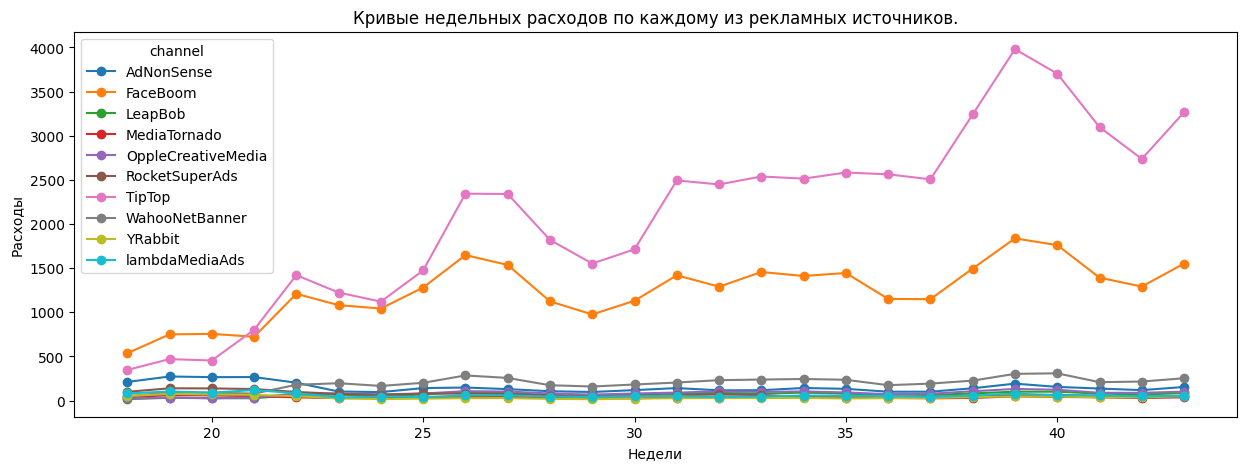

In [ ]:
# Построим график
costs_week= (costs.groupby(['week', 'channel'])
              .agg({'costs': 'sum'})
              .reset_index()
              .sort_values(['week'], ascending=True)
        )

costs_week.pivot(index='week', columns='channel', values='costs').plot(
    kind='line', figsize=(15, 5), marker='o'
)
plt.xlabel('Недели')  # название оси X
plt.ylabel('Расходы')  # название оси Y
plt.title('Кривые недельных расходов по каждому из рекламных источников.')  # название графика
plt.show()

##### На другом графике визуализируем динамику изменения расходов во времени по месяцам по каждому источнику.

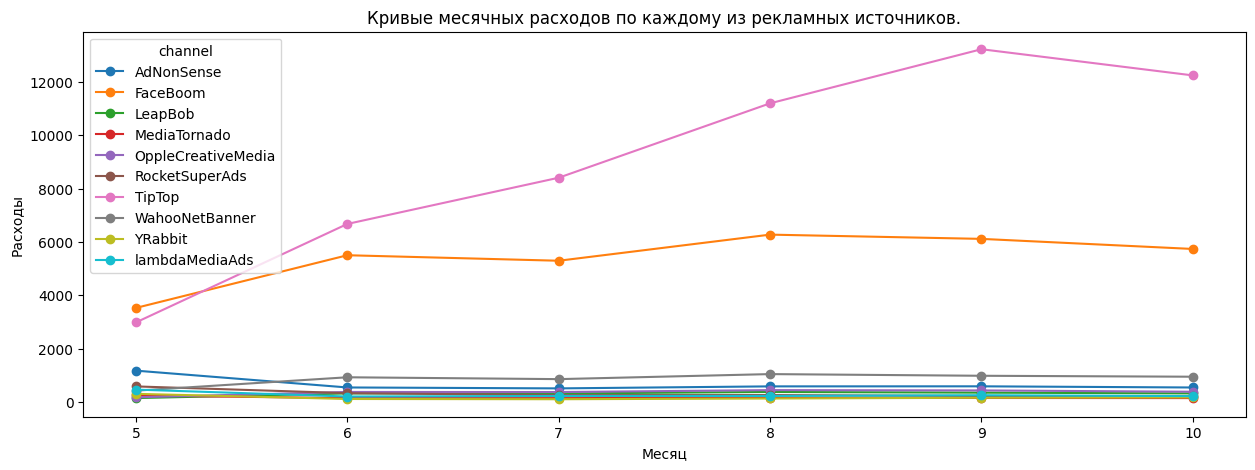

In [ ]:
# Построим график
costs_month =(costs.groupby(['month', 'channel'])
              .agg({'costs': 'sum'})
              .reset_index()
              .sort_values(['month'], ascending=True)
             )

costs_month.pivot(index='month', columns='channel', values='costs').plot(
    kind='line', figsize=(15, 5), marker='o'
)
plt.xlabel('Месяц')  # название оси X
plt.ylabel('Расходы')  # название оси Y
plt.title('Кривые месячных расходов по каждому из рекламных источников.')  # название графика
plt.show()

#### Узнаем, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника. Используйте профили пользователей.

In [ ]:
profiles.groupby('channel') \
        .agg ({'acquisition_cost': 'mean'}) \
        .sort_values('acquisition_cost', ascending = False)

,acquisition_cost
channel,
TipTop,2.799003
FaceBoom,1.113286
AdNonSense,1.008054
lambdaMediaAds,0.724802
WahooNetBanner,0.602245
RocketSuperAds,0.412095
OppleCreativeMedia,0.250000
YRabbit,0.218975
MediaTornado,0.218717


Вывод:

* Хорошо заметны большие траты по двум рекламным каналам: TipTop, FaceBoom. Это видно как на месячном, так и на недельном графике, траты со временем только растут. При этом стоимость привлечения клиентов одна из самых высоких: TipTop — 2,7\$, FaceBoom — 1,1\$. На них тратится больше 80% всего бюджета.

### Оценим окупаемость рекламы

Используя графики LTV, ROI и CAC, проанализируем окупаемость рекламы. Будем считать, что на календаре 1 ноября 2019 года, и в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения. Необходимость включения в анализ органических пользователей определим самостоятельно.

* Проанализируем окупаемость рекламы с помощью графиков LTV и ROI, а также графиков динамики LTV, CAC и ROI.
* Проверим конверсию пользователей и динамику её изменения. То же самое сделаем с удержанием пользователей. Построим и изучим графики конверсии и удержания.
* Проанализируем окупаемость рекламы с разбивкой по устройствам. Построим графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
* Проанализируем окупаемость рекламы с разбивкой по странам. Построим графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
* Проанализируем окупаемость рекламы с разбивкой по рекламным каналам. Построим графики LTV и ROI, а также графики динамики LTV, CAC и ROI.

Ответим на такие вопросы:

* Окупается ли реклама, направленная на привлечение пользователей в целом?
* Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?
* Чем могут быть вызваны проблемы окупаемости?

Напишем вывод, опишем возможные причины обнаруженных проблем и дадим промежуточные рекомендации для рекламного отдела.

#### Проанализируем окупаемость рекламы с помощью графиков LTV и ROI, а также графиков динамики LTV, CAC и ROI.

In [ ]:
# Не будем учитывать клиентов, пришедших через канал organic, по причине «условной бесплатности».
profiles_no = profiles.query('channel != "organic"')

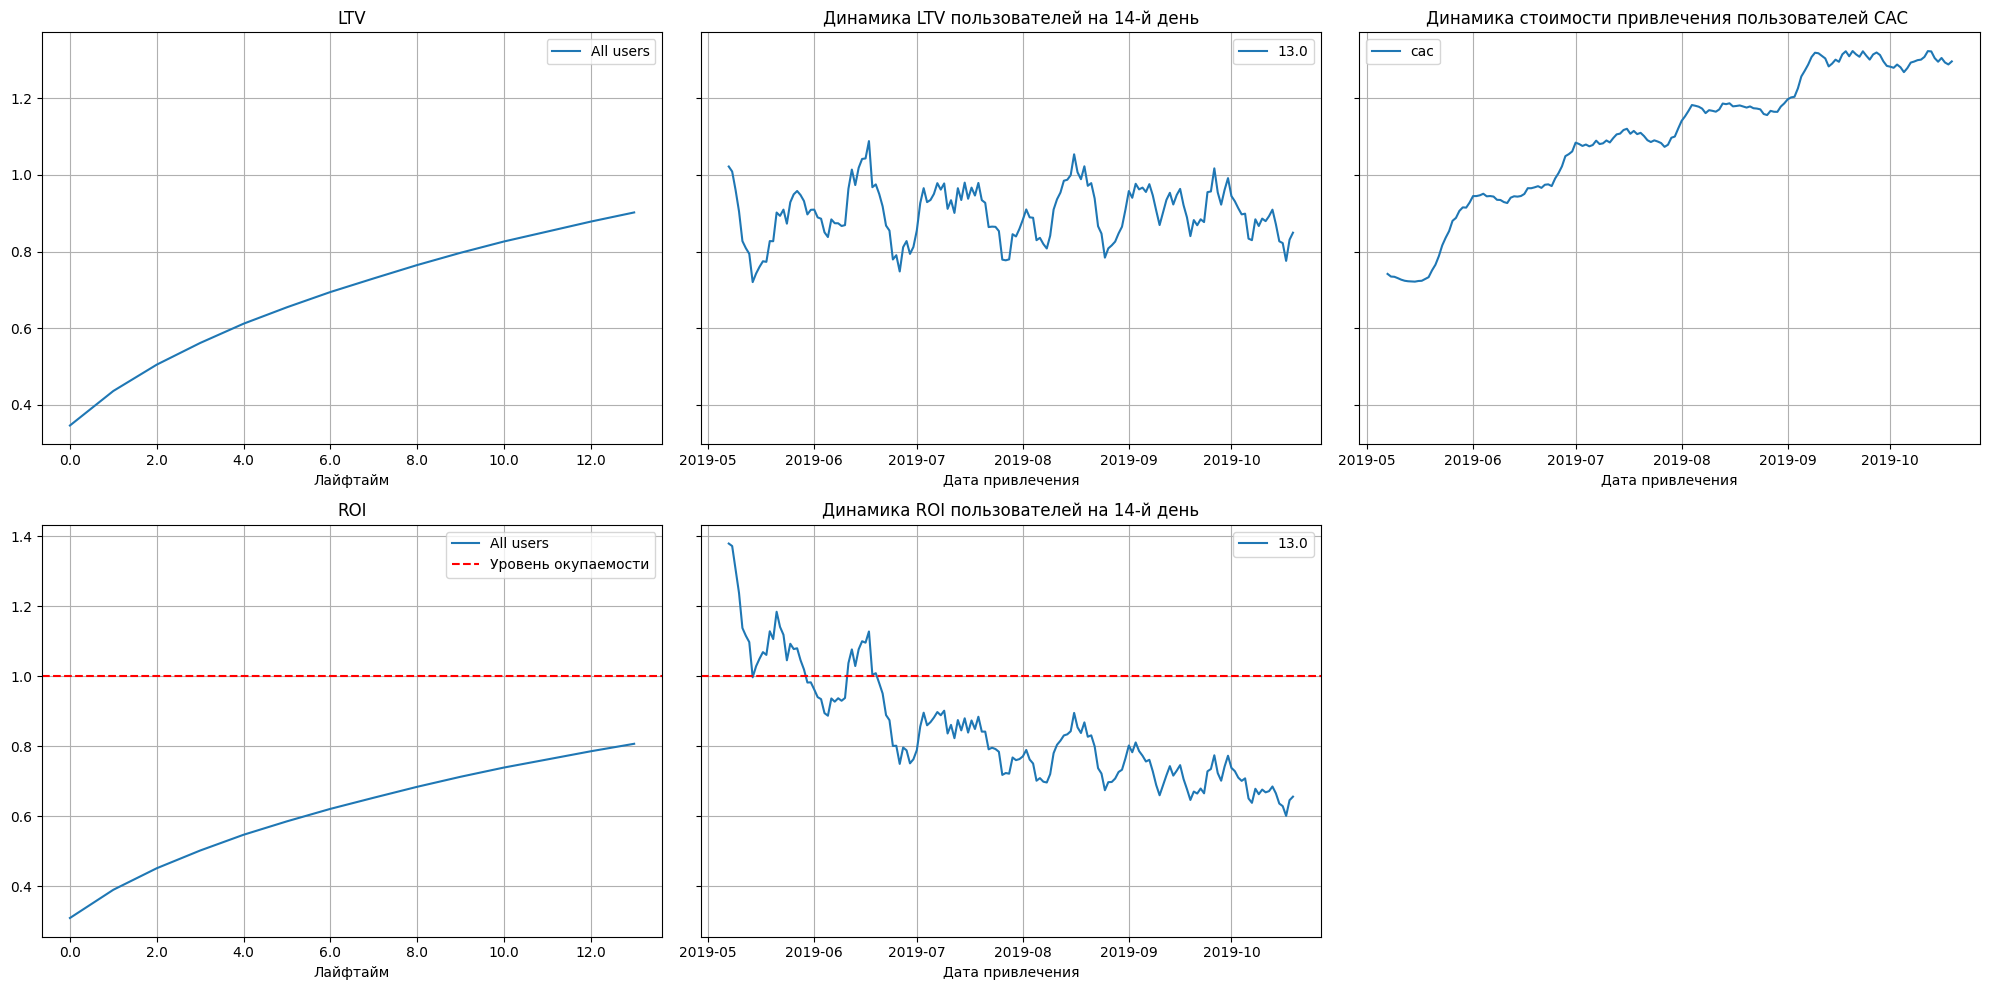

In [ ]:
# Приведем расчеты окупаемости рекламы.
ltv_raw,ltv_grouped,ltv_history,roi_grouped,roi_history = get_ltv ( profiles_no,
                                                                    orders,
                                                                    observation_date,
                                                                    horizon_days
                                                                  )
# Визуализируем полученные данные.
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)

Основываясь на данных графиков, можно сделать следующие заключения:

- Рекламы не приносят прибыль. К концу второй недели показатель рентабельности инвестиций (ROI) составляет 80%.
- Стоимость привлечения клиента (CAC) увеличивается почти непрерывно, причём не постепенно, а скачкообразно. Это означает, что рекламные кампании проводятся регулярно.
- Показатель пожизненной ценности клиента (LTV) остаётся стабильным. Это говорит о том, что клиенты имеют примерно одинаковое качество.

#### Проверим конверсию пользователей и динамику её изменения. То же самое сделаем с удержанием пользователей. Построим и изучим графики конверсии и удержания с разбивкой по устройствам, странам, рекламным каналам.

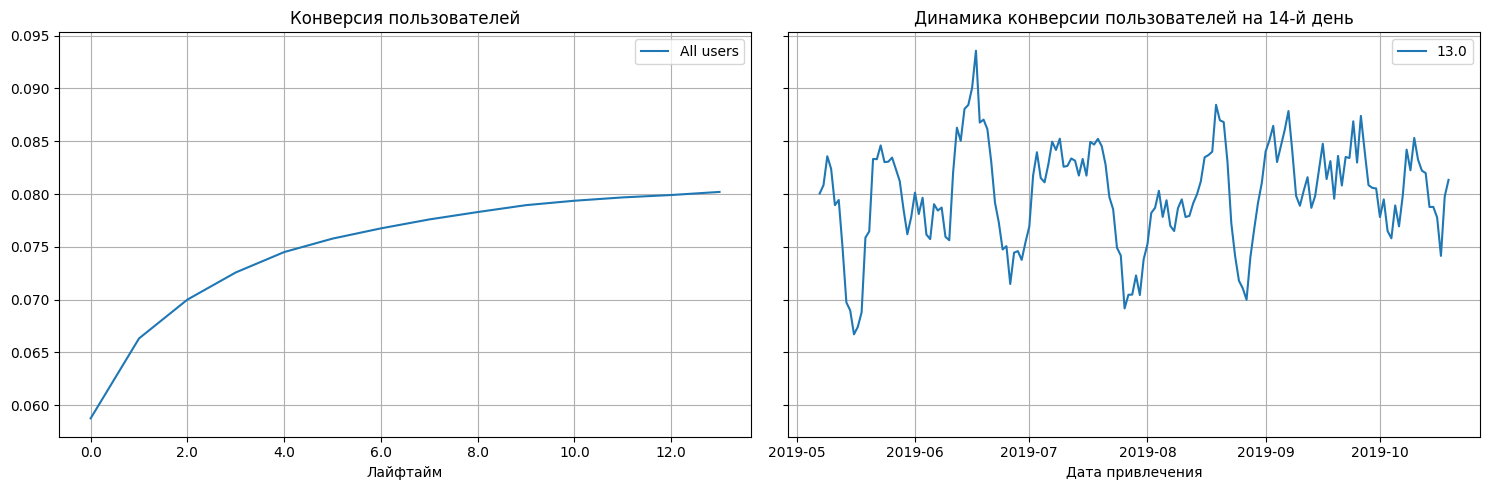

In [ ]:
# Рассчитаем конверсию пользователей.
conversion_raw, conversion_grouped, conversion_history = get_conversion(profiles_no,
                                                                        orders,
                                                                        observation_date,
                                                                        horizon_days,
                                                                       )
# Визуализируем полученные данные.
plot_conversion(conversion_grouped, conversion_history, horizon_days)

Анализируя графики, можно сделать следующие заключения:
Конверсия посетителей в покупателей плавно растет.

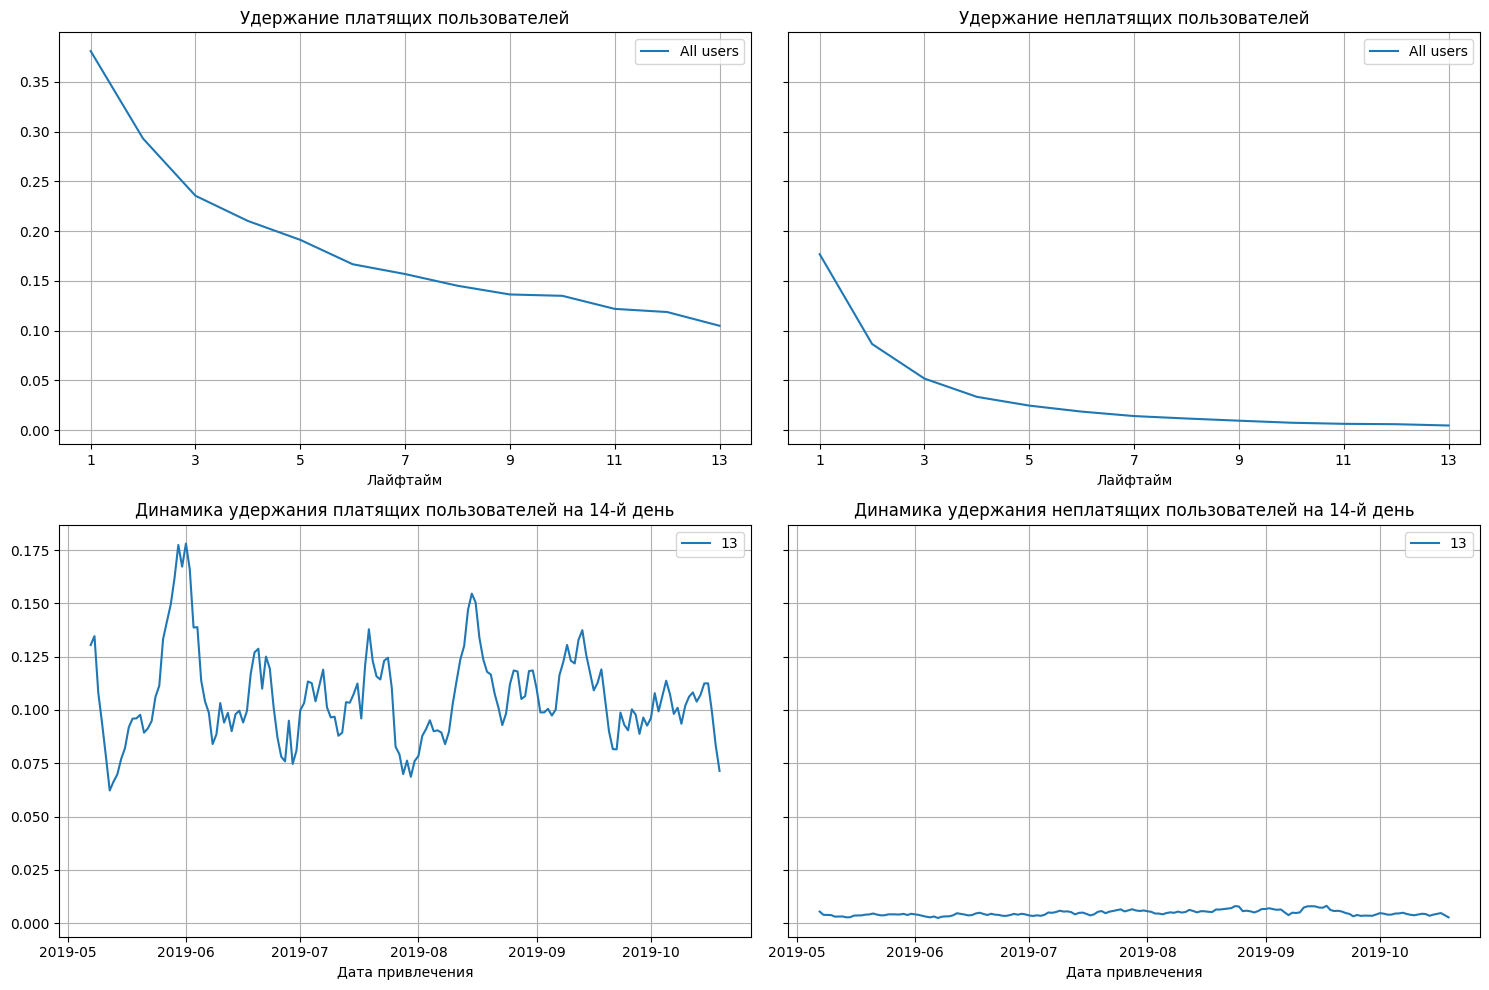

In [ ]:
#Рассчитаем удержание пользователей.
retention_raw, retention_grouped, retention_history = get_retention(profiles_no, visits,
                                                                    observation_date,
                                                                    horizon_days
                                                                   )
# Визуализируем полученные данные.
plot_retention(retention_grouped, retention_history, horizon_days)

Анализируя графики, можно сделать следующие заключения:
 - Удержание платящих и не платящих пользователей разное, платящие пользователи удерживаются лучше не платящих.

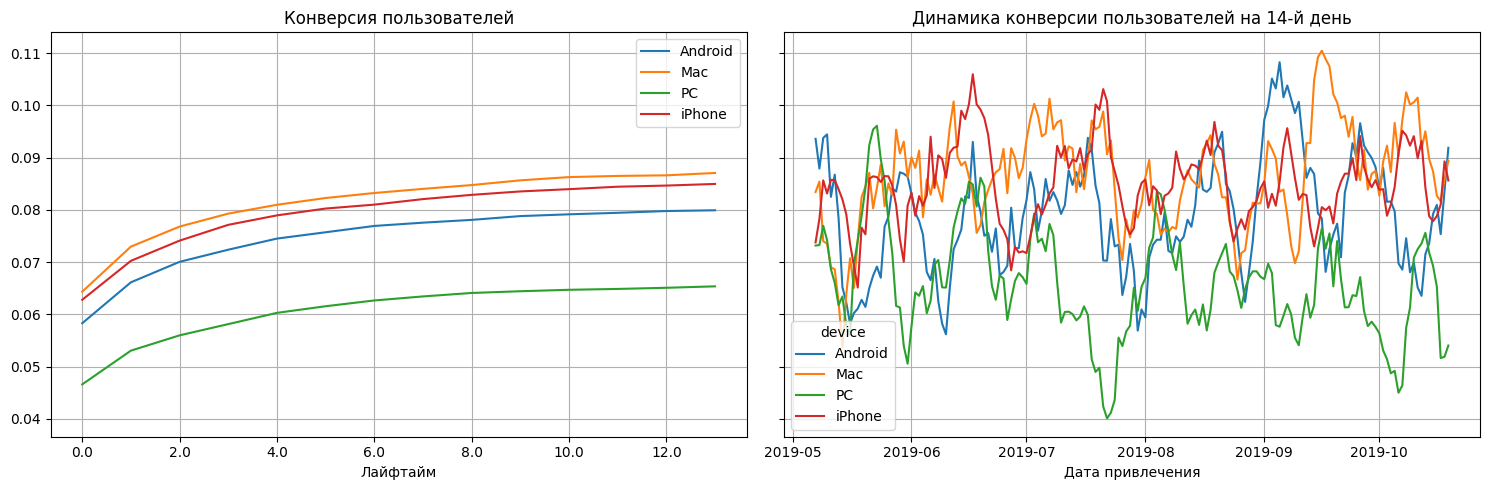

In [ ]:
# Рассчитаем конверсию с разбивкой по устройствам.
conversion_raw, conversion_grouped, conversion_history = get_conversion(profiles_no,
                                                                        orders,
                                                                        observation_date,
                                                                        horizon_days,
                                                                        dimensions=['device']
                                                                       )
# Визуализируем полученные данные.
plot_conversion(conversion_grouped, conversion_history, horizon_days)

Анализируя графики, можно сделать следующие заключения: пользователи устройств MAC и iPhone чаще становятся покупателями.

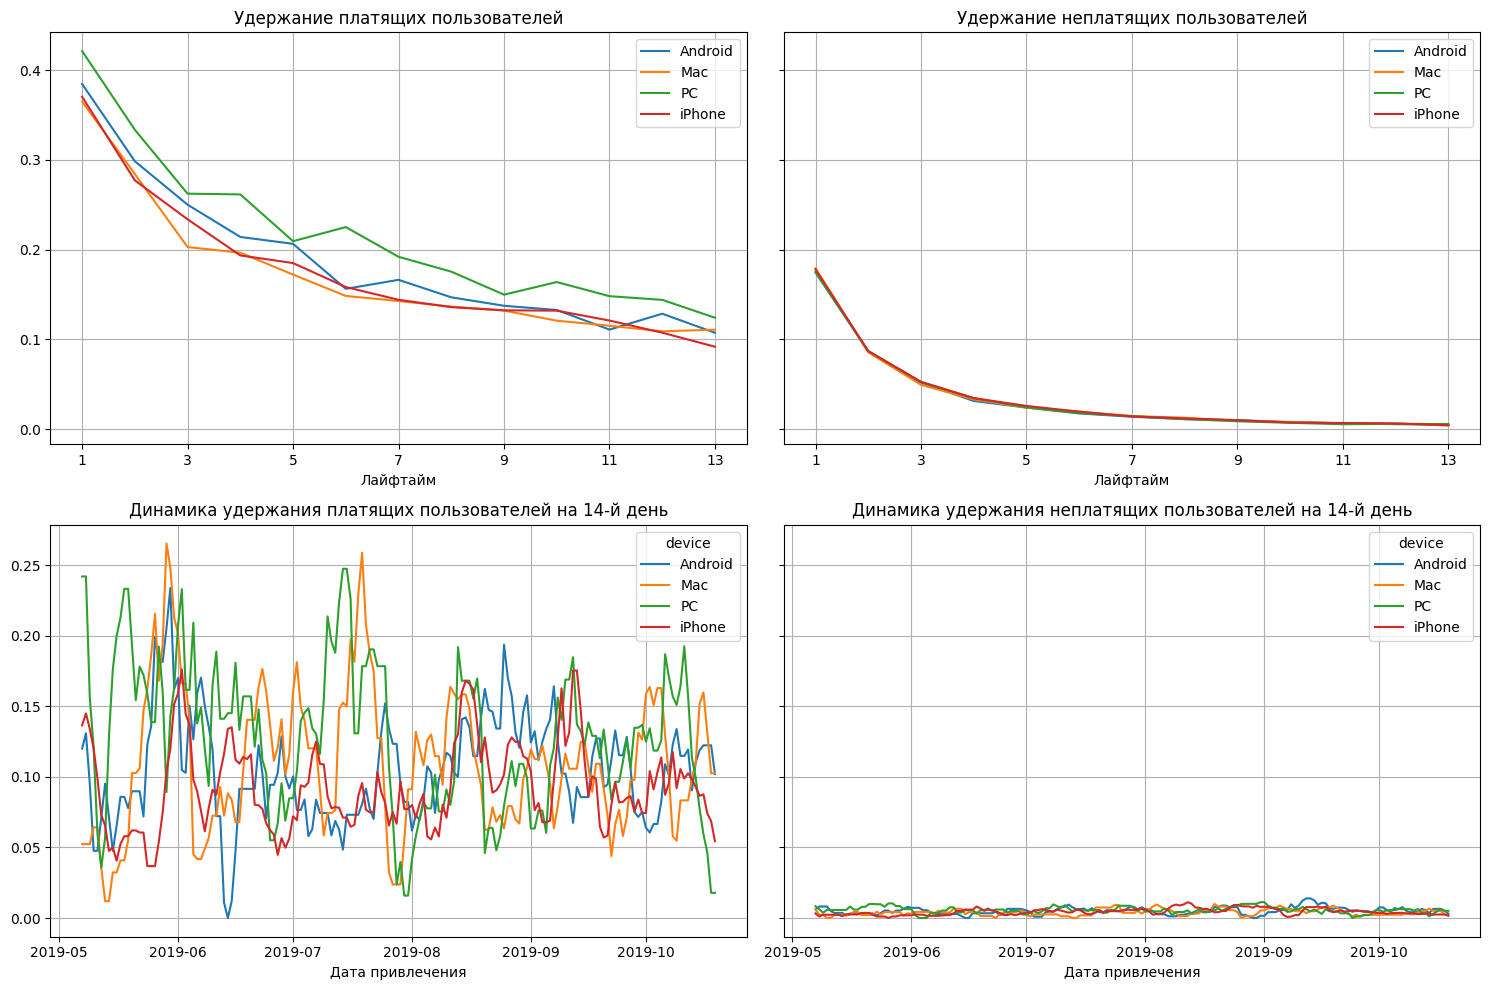

In [ ]:
#Рассчитаем удержание с разбивкой по устройствам.
retention_raw, retention_grouped, retention_history = get_retention(profiles_no, visits,
                                                                    observation_date,
                                                                    horizon_days ,
                                                                    dimensions=['device']
                                                                   )
# Визуализируем полученные данные.
plot_retention(retention_grouped, retention_history, horizon_days)

Анализируя графики, можно сделать следующие заключения:
  - Удержание платящих пользователей имеет некоторые закономерности: те пользователи, которые хорошо конвертируются в покупателей, хуже удерживаются. То есть по графику конверсии видно, что лучше всех конвертируются пользователи MAC и iPhone, при этом по графику удержания видно, что они хуже всех удерживаются. «Ветреные ребята». Напротив, пользователи PC хуже всех конвертируются, при этом лучше остальных удерживаются.  

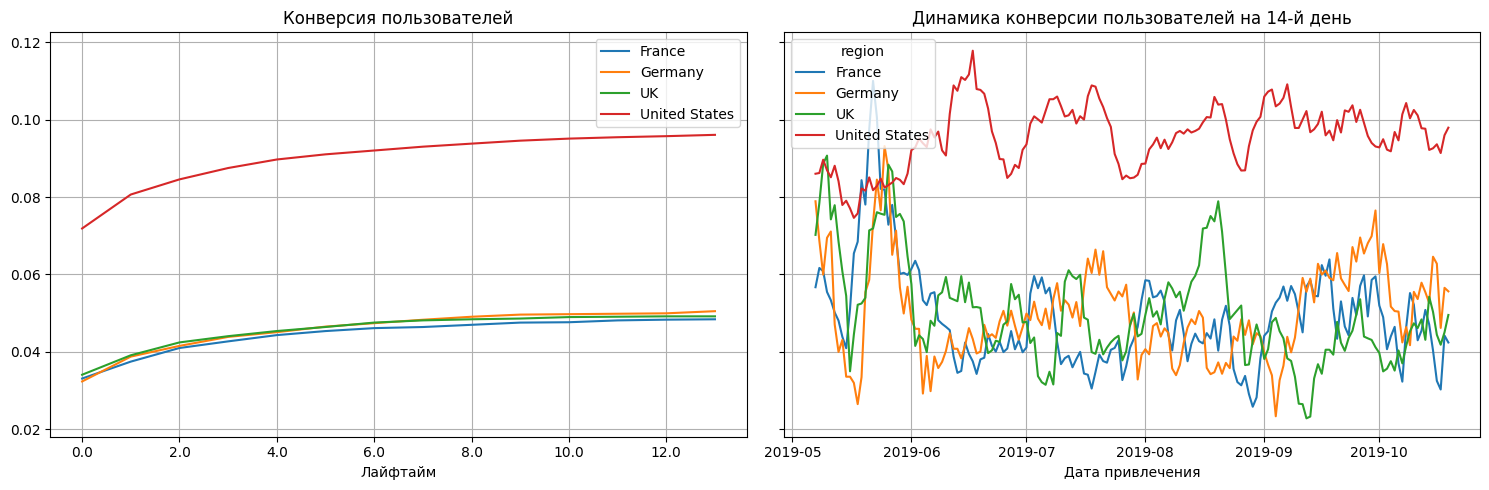

In [ ]:
# Рассчитаем конверсию с разбивкой по регионам .
conversion_raw, conversion_grouped, conversion_history = get_conversion(profiles_no,
                                                                        orders,
                                                                        observation_date,
                                                                        horizon_days,
                                                                        dimensions=['region']
                                                                       )
# Визуализируем полученные данные.
plot_conversion(conversion_grouped, conversion_history, horizon_days)

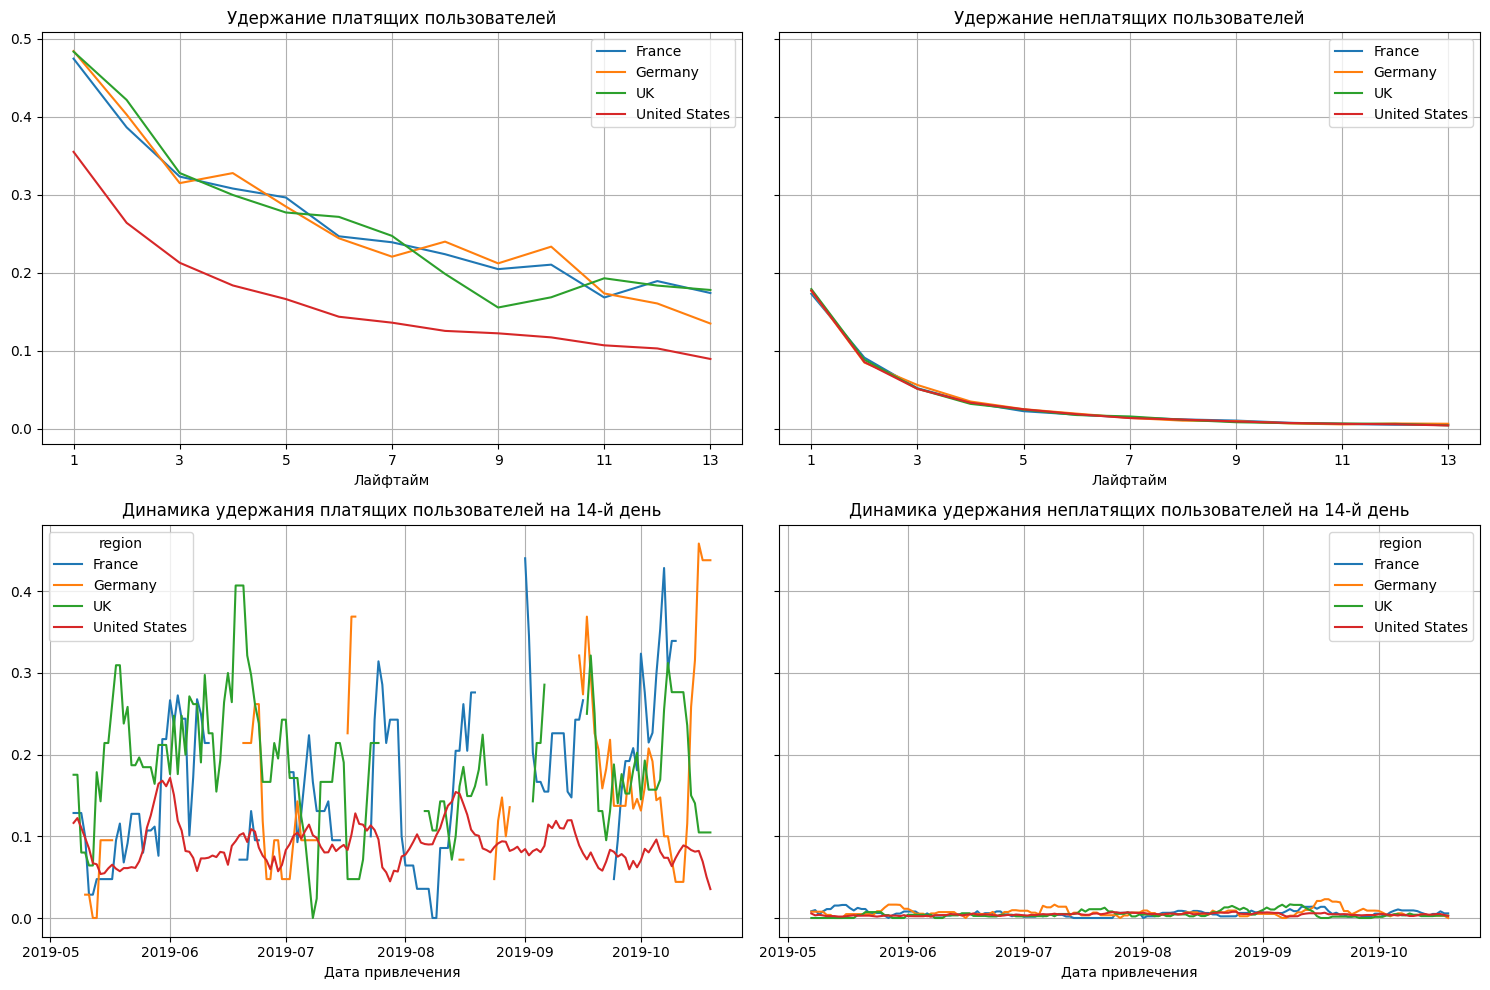

In [ ]:
#Рассчитаем удержание с разбивкой по регионам.
retention_raw, retention_grouped, retention_history = get_retention(profiles_no, visits,
                                                                    observation_date,
                                                                    horizon_days ,
                                                                    dimensions=['region']
                                                                   )
# Визуализируем полученные данные.
plot_retention(retention_grouped, retention_history, horizon_days)

Анализируя графики, можно сделать следующие заключения: конверсия пользователей из США значительно выше, чем по другим регионам. В других регионах она почти одинакова. Удержание же, наоборот, в США пользователи «отваливаются» чаще, чем по другим регионам.

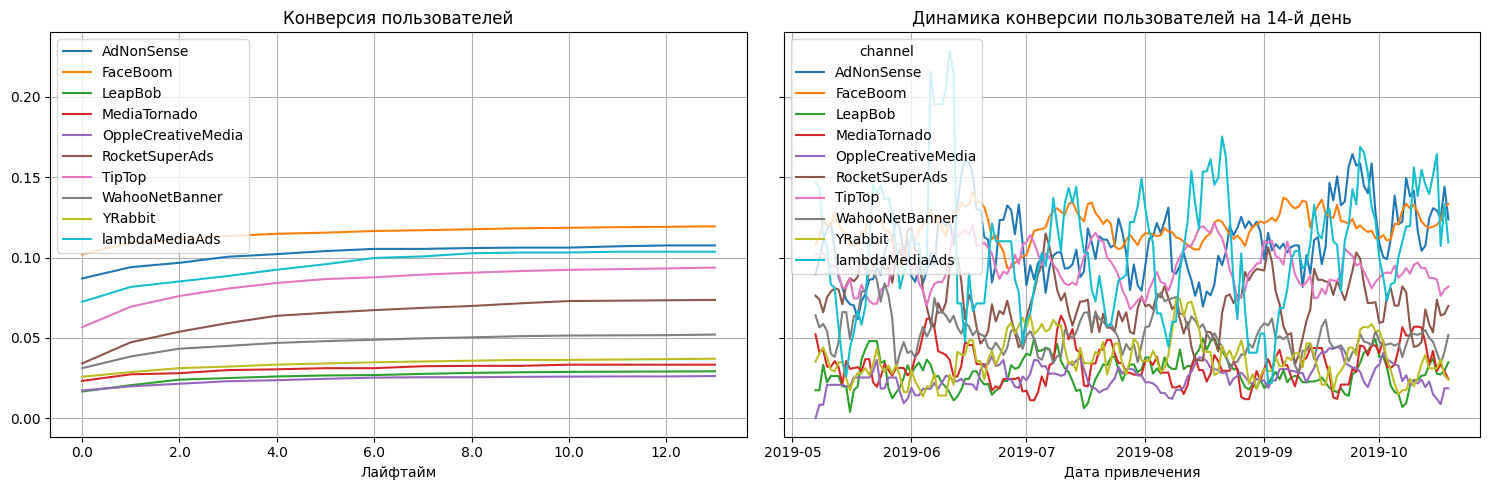

In [ ]:
# Рассчитаем конверсию с разбивкой по рекламным каналам .
conversion_raw, conversion_grouped, conversion_history = get_conversion(profiles_no,
                                                                        orders,
                                                                        observation_date,
                                                                        horizon_days,
                                                                        dimensions=['channel']
                                                                       )
# Визуализируем полученные данные.
plot_conversion(conversion_grouped, conversion_history, horizon_days)

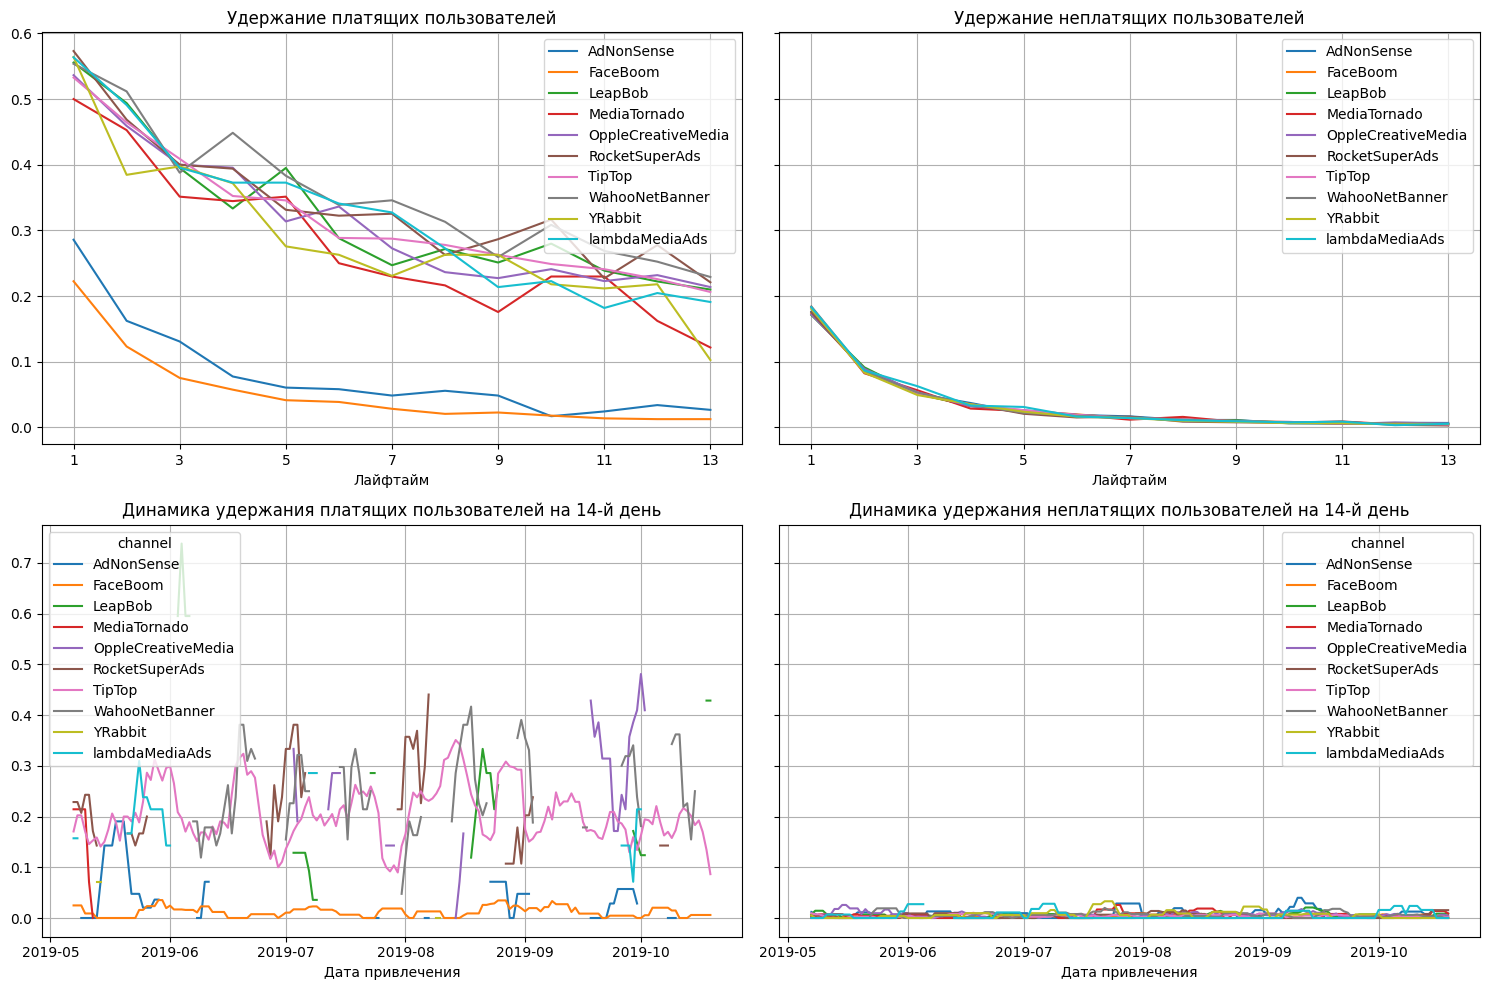

In [ ]:
#Рассчитаем удержание с разбивкой по рекламным каналам .
retention_raw, retention_grouped, retention_history = get_retention(profiles_no, visits,
                                                                    observation_date,
                                                                    horizon_days ,
                                                                    dimensions=['channel']
                                                                   )
# Визуализируем полученные данные.
plot_retention(retention_grouped, retention_history, horizon_days)

Анализируя графики, можно сделать следующие заключения: рекламные каналы с самой высокой конверсией FaceBoom и AdNonSense имеют самое низкое удержание. Похоже на то, что рекламный канал привлекает нецелевую аудиторию.

#### Проанализируем окупаемость рекламы с разбивкой по устройствам. Построим графики LTV и ROI, а также графики динамики LTV, CAC и ROI.

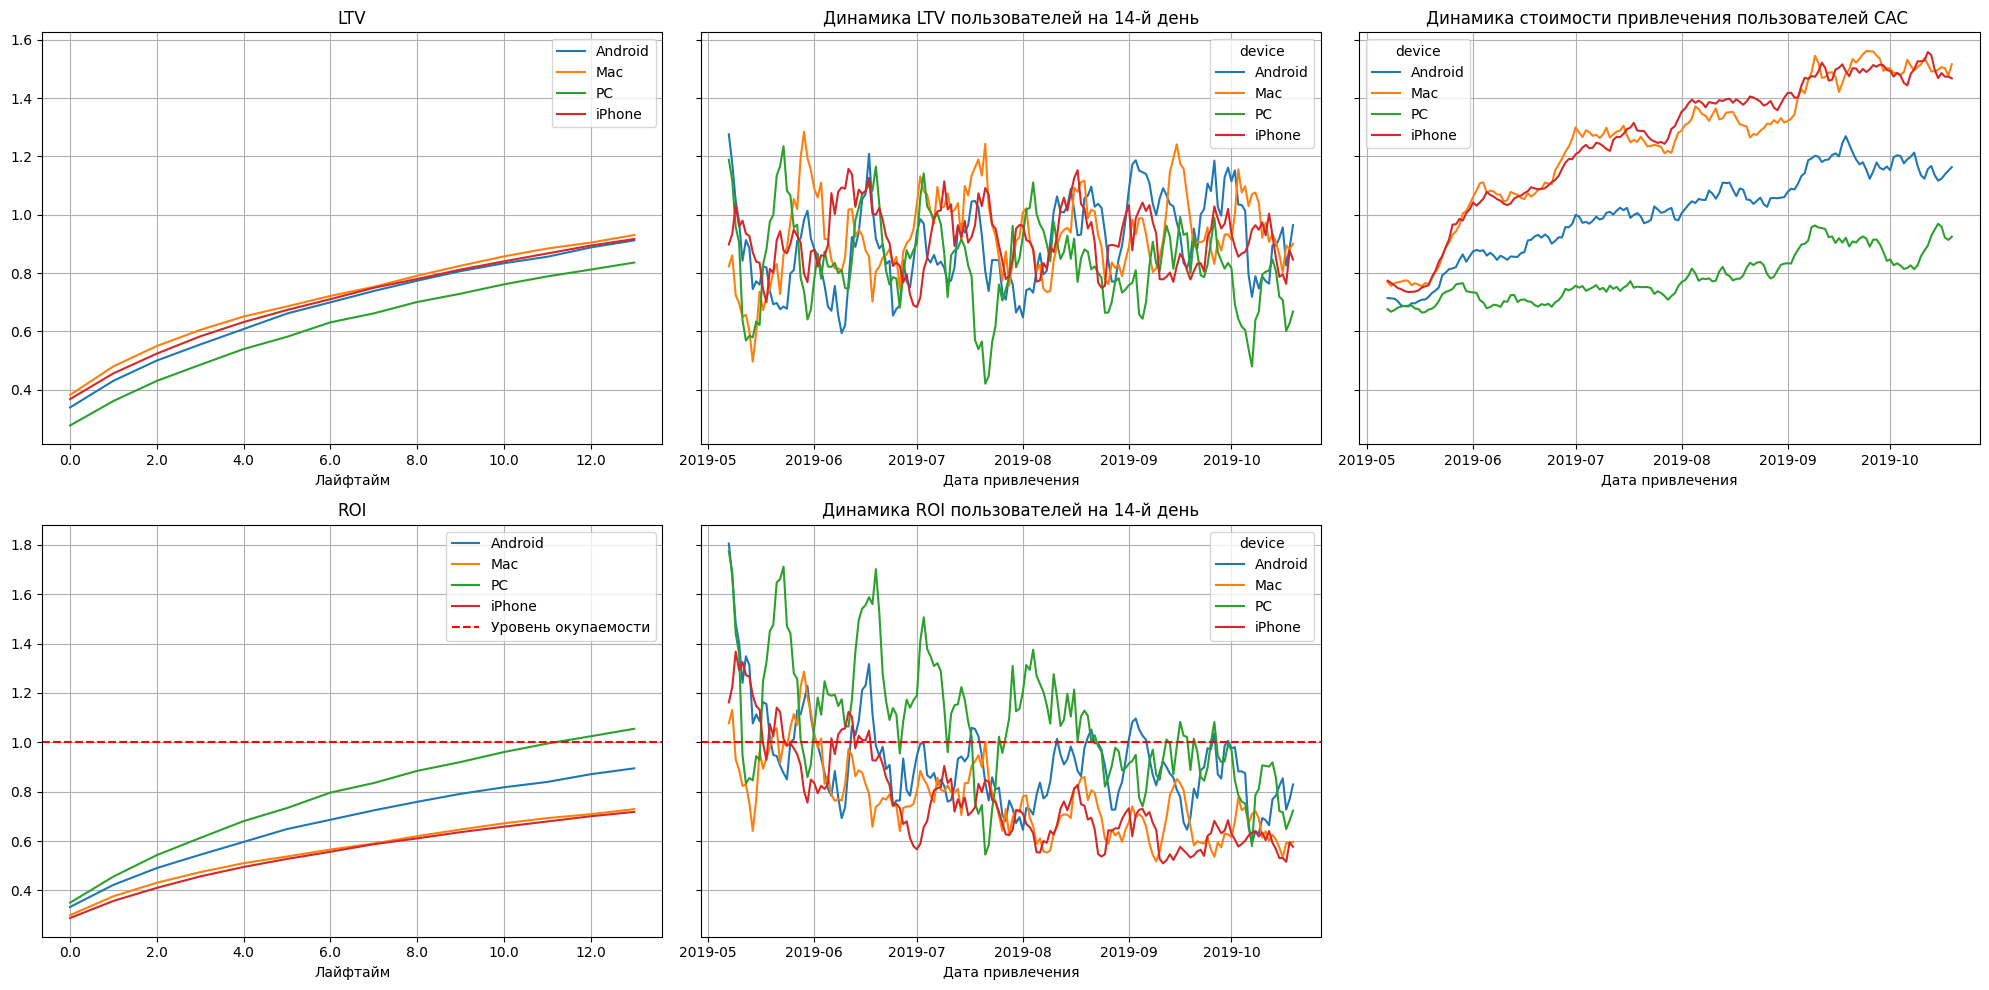

In [ ]:
#Произовдим расчета с вразбивкой по устройствам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles_no,
                                                                      orders,
                                                                      observation_date,
                                                                      horizon_days,
                                                                      dimensions=['device']
                                                                     )
# Визуализируем полученные данные
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=7)

Анализируя графики, можно сделать следующие заключения:

- Рекламные кампании не приносят прибыли на всех платформах, за исключением  пользователей PC.
- Стоимость привлечения клиента (CAC) увеличивается на всех платформах.
- Показатель пожизненной ценности клиента (LTV) остаётся стабильным на всех платформах.
- Наименее успешными в плане окупаемости являются владельцы устройств Mac и iPhone.

#### Проанализируем окупаемость рекламы с разбивкой по странам. Построим графики LTV и ROI, а также графики динамики LTV, CAC и ROI.

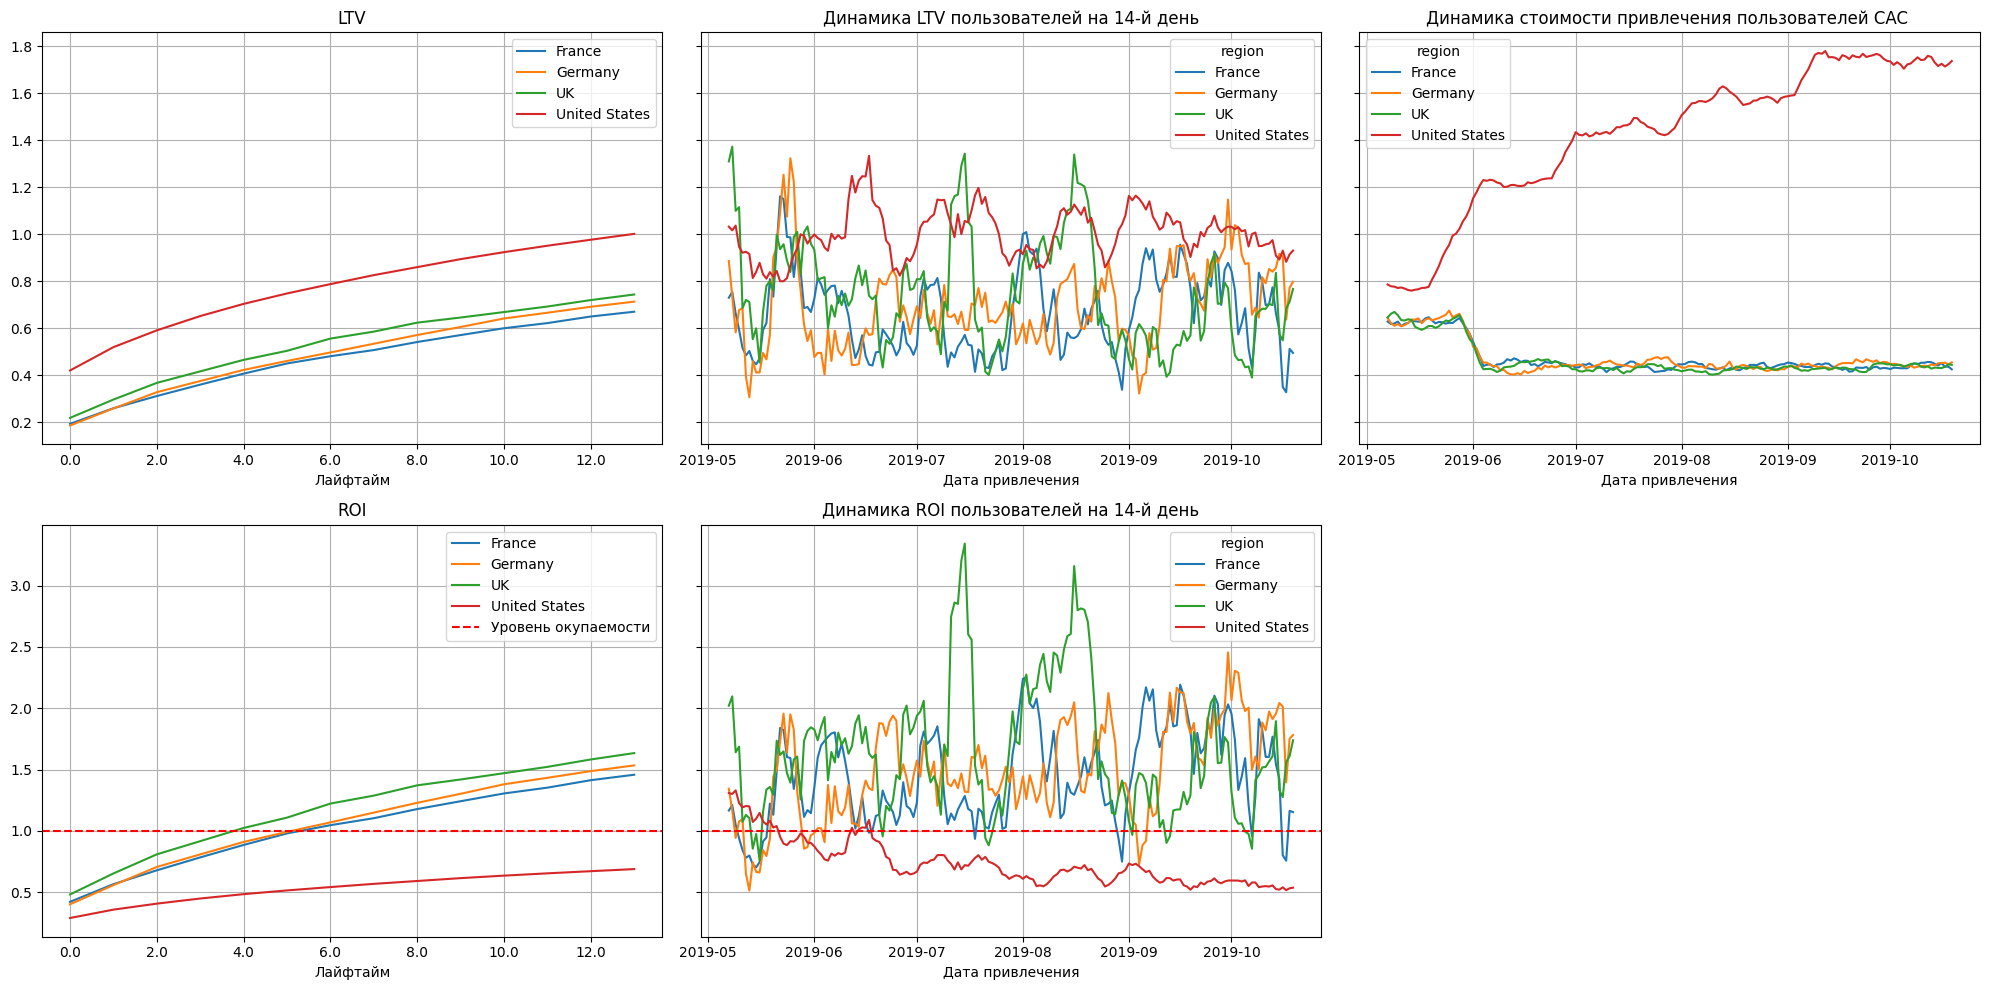

In [ ]:
#Произовдим расчета с вразбивкой по странам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles_no,
                                                                      orders,
                                                                      observation_date,
                                                                      horizon_days,
                                                                      dimensions=['region']
                                                                     )
# Визуализируем полученные данные
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=7)

Основываясь на графиках, можно сделать следующие заключения:

- LTV остаётся стабильным во всех регионах, также стоит обратить внимание, что пользователи из США покупают чаще.
- В США наблюдается постоянный рост CAC, в то время как в других странах в июне происходит резкое снижение этого показателя, после чего он остаётся на стабильно низком уровне.
- Реклама в США не окупается, в других странах реклама начинает приносить прибыль уже на шестой день.

####  Проанализируем окупаемость рекламы с разбивкой по рекламным каналам. Построим графики LTV и ROI, а также графики динамики LTV, CAC и ROI.

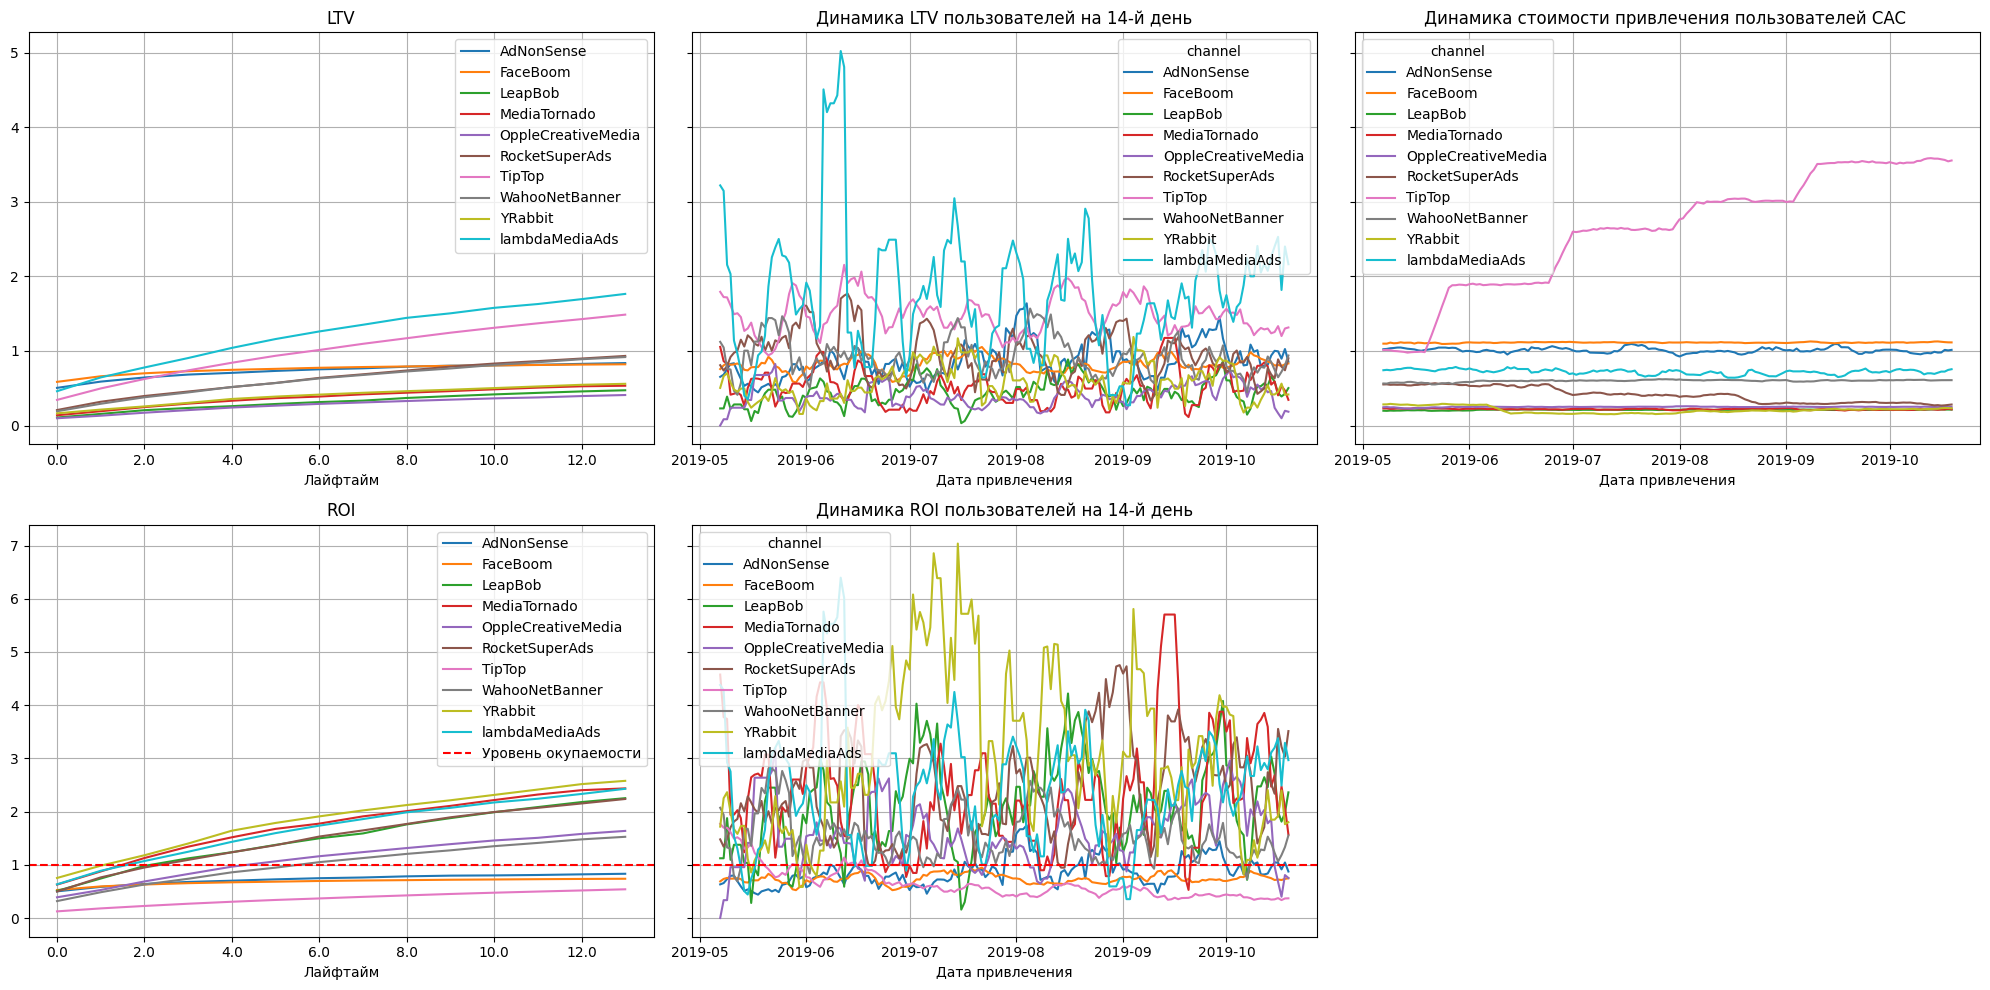

In [ ]:
#Произовдим расчета с разбивкой по рекламным каналам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles_no,
                                                                      orders,
                                                                      observation_date,
                                                                      horizon_days,
                                                                      dimensions=['channel']
                                                                     )
# Визуализируем полученные данные
plot_ltv_roi( ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=7)

На основе анализа графиков можно сделать следующие заключения:

- LTV сохраняет стабильность во всех каналах, наиболее платящие клиенты приходят из канала lambdaMediaAds .
- В TipTop наблюдается рост CAC, в то время как в остальных каналах этот показатель остаётся на стабильно низком уровне или даже немного снижается.
- В большинстве каналов, за исключением TipTop, FaceBoom и AdNonSense, рекламные кампании приносят прибыль.


### Напишем выводы:

* Выделим причины неэффективности привлечения пользователей.
* Сформулируем рекомендации для отдела маркетинга.

Окупается ли реклама, направленная на привлечение пользователей в целом?

 - Реклама не окупается. Окупаемость к концу второй недели не более 80%.

Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?

 - По устройствам окупаются лишь те клиенты, которые используют PC.

 - По странам не окупаются лишь клиенты из США.

 - TipTop, FaceBoom и AdNonSense. Клиенты, пришедшие из них, не окупятся.

Чем могут быть вызваны проблемы окупаемости?

 - Проблема связана с тем, что большая часть бюджета — 86% — распределяется на неэффективные рекламные каналы, такие как TipTop, FaceBoom и AdNonSense.


Результаты исследования:

Мы провели анализ активности пользователей и эффективности маркетинговых расходов за последние полгода.

Выяснилось, что количество пользователей приложения в США значительно превышает суммарное количество пользователей в других странах. При этом американцы совершают покупки чаще, чем пользователи из других стран. Однако стоимость привлечения одного покупателя из США примерно в полтора раза выше, чем из других стран.

Тип устройства, с которого совершаются покупки, не имеет большого значения, поскольку окупаются только пользователи, использующие компьютеры.

Почти половина рекламного бюджета приложения была потрачена на площадку TipTop, при этом у него самая низная окупаемость.В среднем стоимость привлечения одного покупателя составила более 2,79 долларов, что делает этот канал очень дорогим для рекламы.

Второй канал, который не окупается, — FaceBoom. У него высокая конверсия, но низкое удержание пользователей. Аналогичная ситуация с площадкой AdNonSense. Вероятно, эти каналы привлекают нецелевую аудиторию.

Рекомендуется перераспределить рекламные бюджеты в пользу более окупаемых каналов, таких как YRabbit и lambdaMediaAds. Оба канала имеют высокий процент покупателей и низкую стоимость их привлечения.
